# NicheMap Neighborhood Analysis Tutorial

This tutorial demonstrates the `nichemap.neighborhood` module for summarizing annotations and calculating cell-type composition around spatial structures across one or more graph-hop distances.

## 1. Imports

In [1]:
from pathlib import Path
from IPython.display import Markdown, display
import os
import sys

sys.path.append(os.path.abspath("C://Users//heyi//Desktop/NicheMap"))

import scanpy as sc
import nichemap.neighborhood as nh


## 2. Load Data

In [2]:
DATA_PATH = Path("../data/SSc_1_1_2_tutorial.h5ad")
OUTPUT_DIR = Path("./outputs/neighborhood")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(DATA_PATH)

adata


AnnData object with n_obs × n_vars = 82224 × 541
    obs: 'x_centroid', 'y_centroid', 'cell_type', 'structure_label'
    var: 'gene_name', 'gene_id'
    uns: 'cell_type_colors', 'structure_label_colors'
    obsm: 'spatial'

## 3. Configure Analysis

Set `TARGET_REGIONS` to one or more spatial structures of interest, such as `["Airway_wall"]` or `["Airway_wall", "Vessel"]`.  
`HOPS` can be a single integer, such as `5`, or a list of neighborhood scales, such as `[1, 2, 3, 5]`.  
`TARGET_CELL_TYPES = None` uses all cell types; provide a list if you only want to analyze selected cell types.

In [3]:
STRUCTURE_COL = "structure_label"
CELL_TYPE_COL = "cell_type"

TARGET_REGIONS = ["Airway_wall"]
HOPS = 5

# Use None for all cell types, or provide a selected list.
TARGET_CELL_TYPES = None

# Example targeted mode:
# TARGET_CELL_TYPES = [
#     "Fibroblast",
#     "Macrophage",
#     "T cell",
#     "B cell",
#     "Plasma",
#     "Myofibroblast",
#     "Monocyte",
# ]


## 4. Review Annotation Categories

`display_annotation_summary` summarizes the cell-type and structure columns, then renders a compact spatial overview colored by the structure column.


### Dataset annotation summary

- **Total cells:** 82,224
- **Cell-type categories:** 22
- **Spatial structure categories:** 7


,count,percentage
Secretory,"12,560",15.28%
Fibroblast,"11,912",14.49%
Macrophage,"11,376",13.84%
Endothelial,"11,158",13.57%
T cell,"6,771",8.23%
Basal,"4,380",5.33%
Ciliated,"4,275",5.20%
DC,"3,442",4.19%
B cell,"2,833",3.45%
Pericyte,"2,577",3.13%

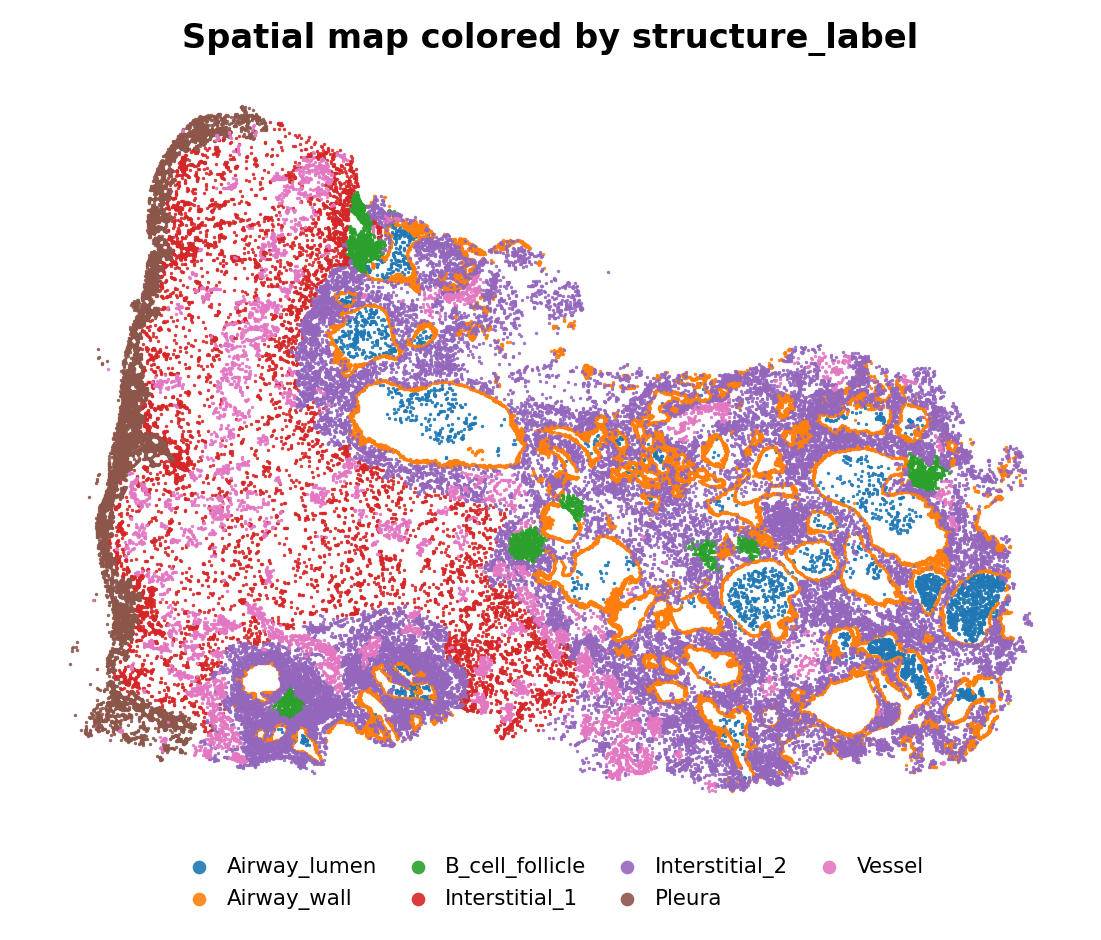

In [4]:
annotation_summary = nh.display_annotation_summary(
    adata,
    cell_type_col=CELL_TYPE_COL,
    structure_col=STRUCTURE_COL,
)


## 5. Run the Full Neighborhood Workflow

The high-level function calculates proportions, saves CSV files, and exports bar plots, spatial topology plots, and the hop-gradient trend plot when multiple hops are supplied.


NicheMap v0.1.0
Spatial Niche and Neighborhood Analysis Toolkit
Cell Types → Structures → Spatial Niches

Dataset      : 82,224 cells × 541 genes
Structures   : ['Airway_wall']
Hops         : 5
Cell types   : All
----------------------------------------------------------------------
>>> 1. Building spatial adjacency matrix...
Spatial adjacency matrix is ready. Time used: 44.23 seconds


Neighborhood analysis:   0%|          | 0/1 [00:00<?, ?hop/s]

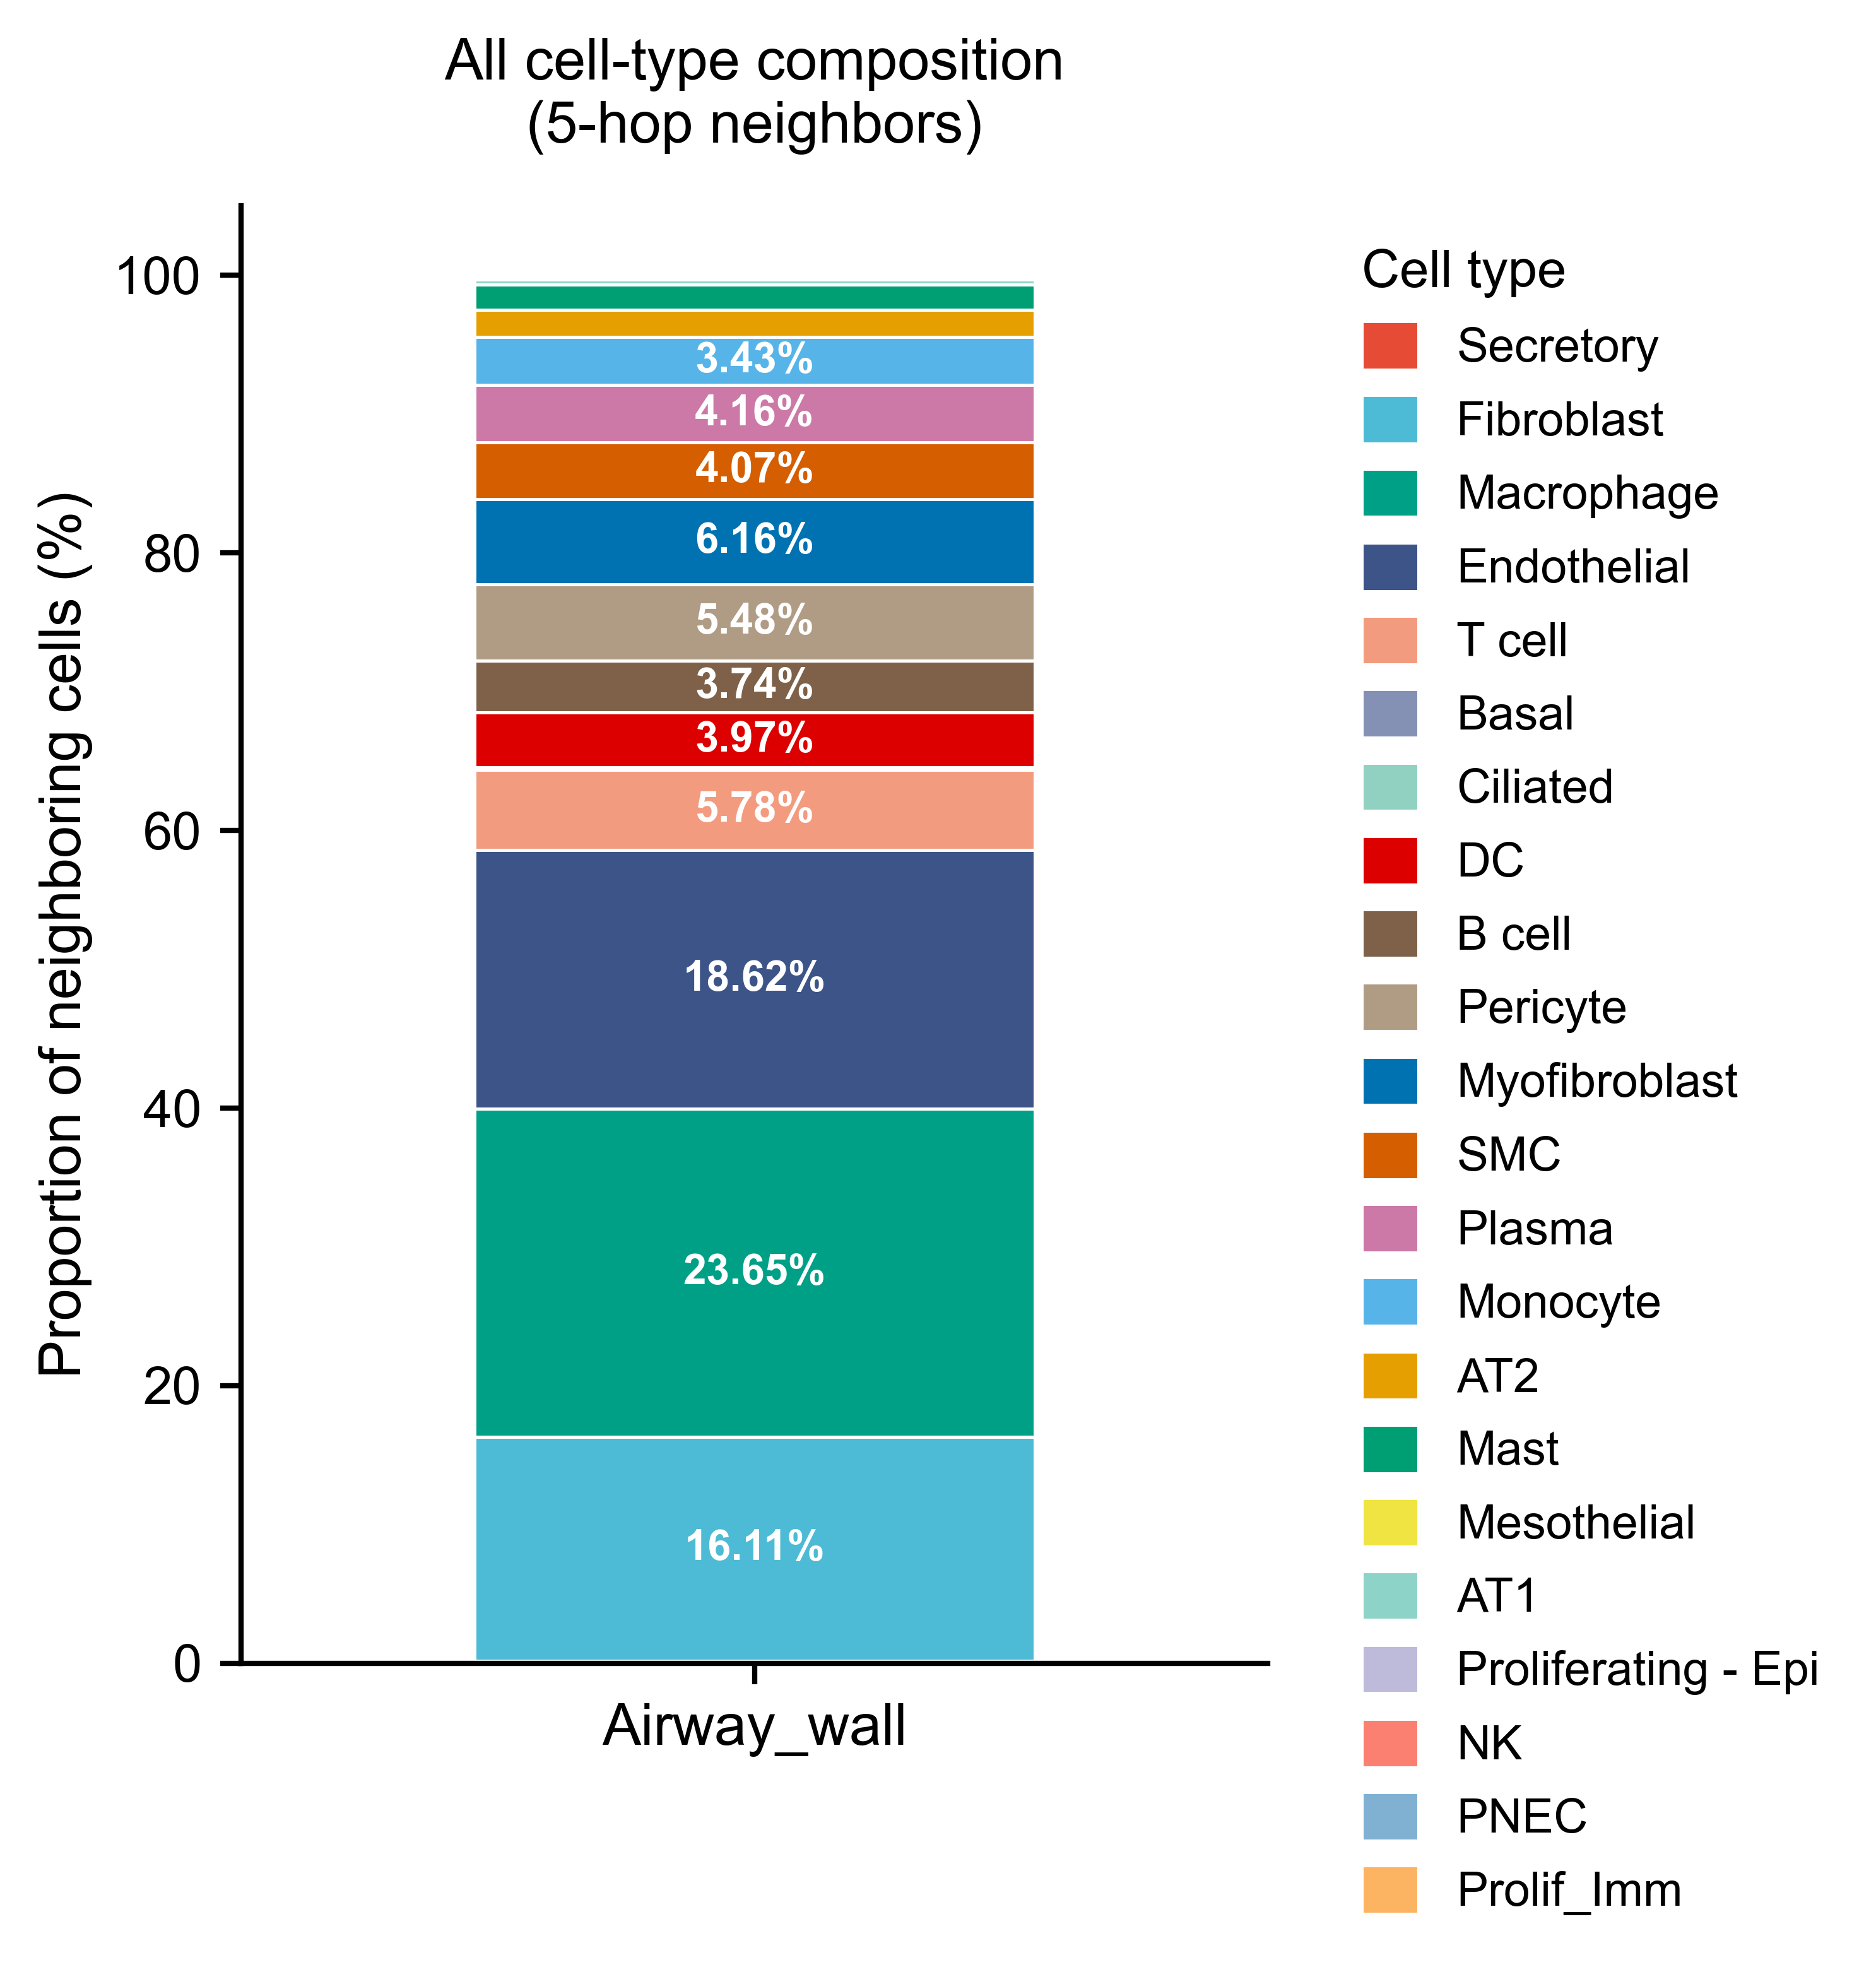

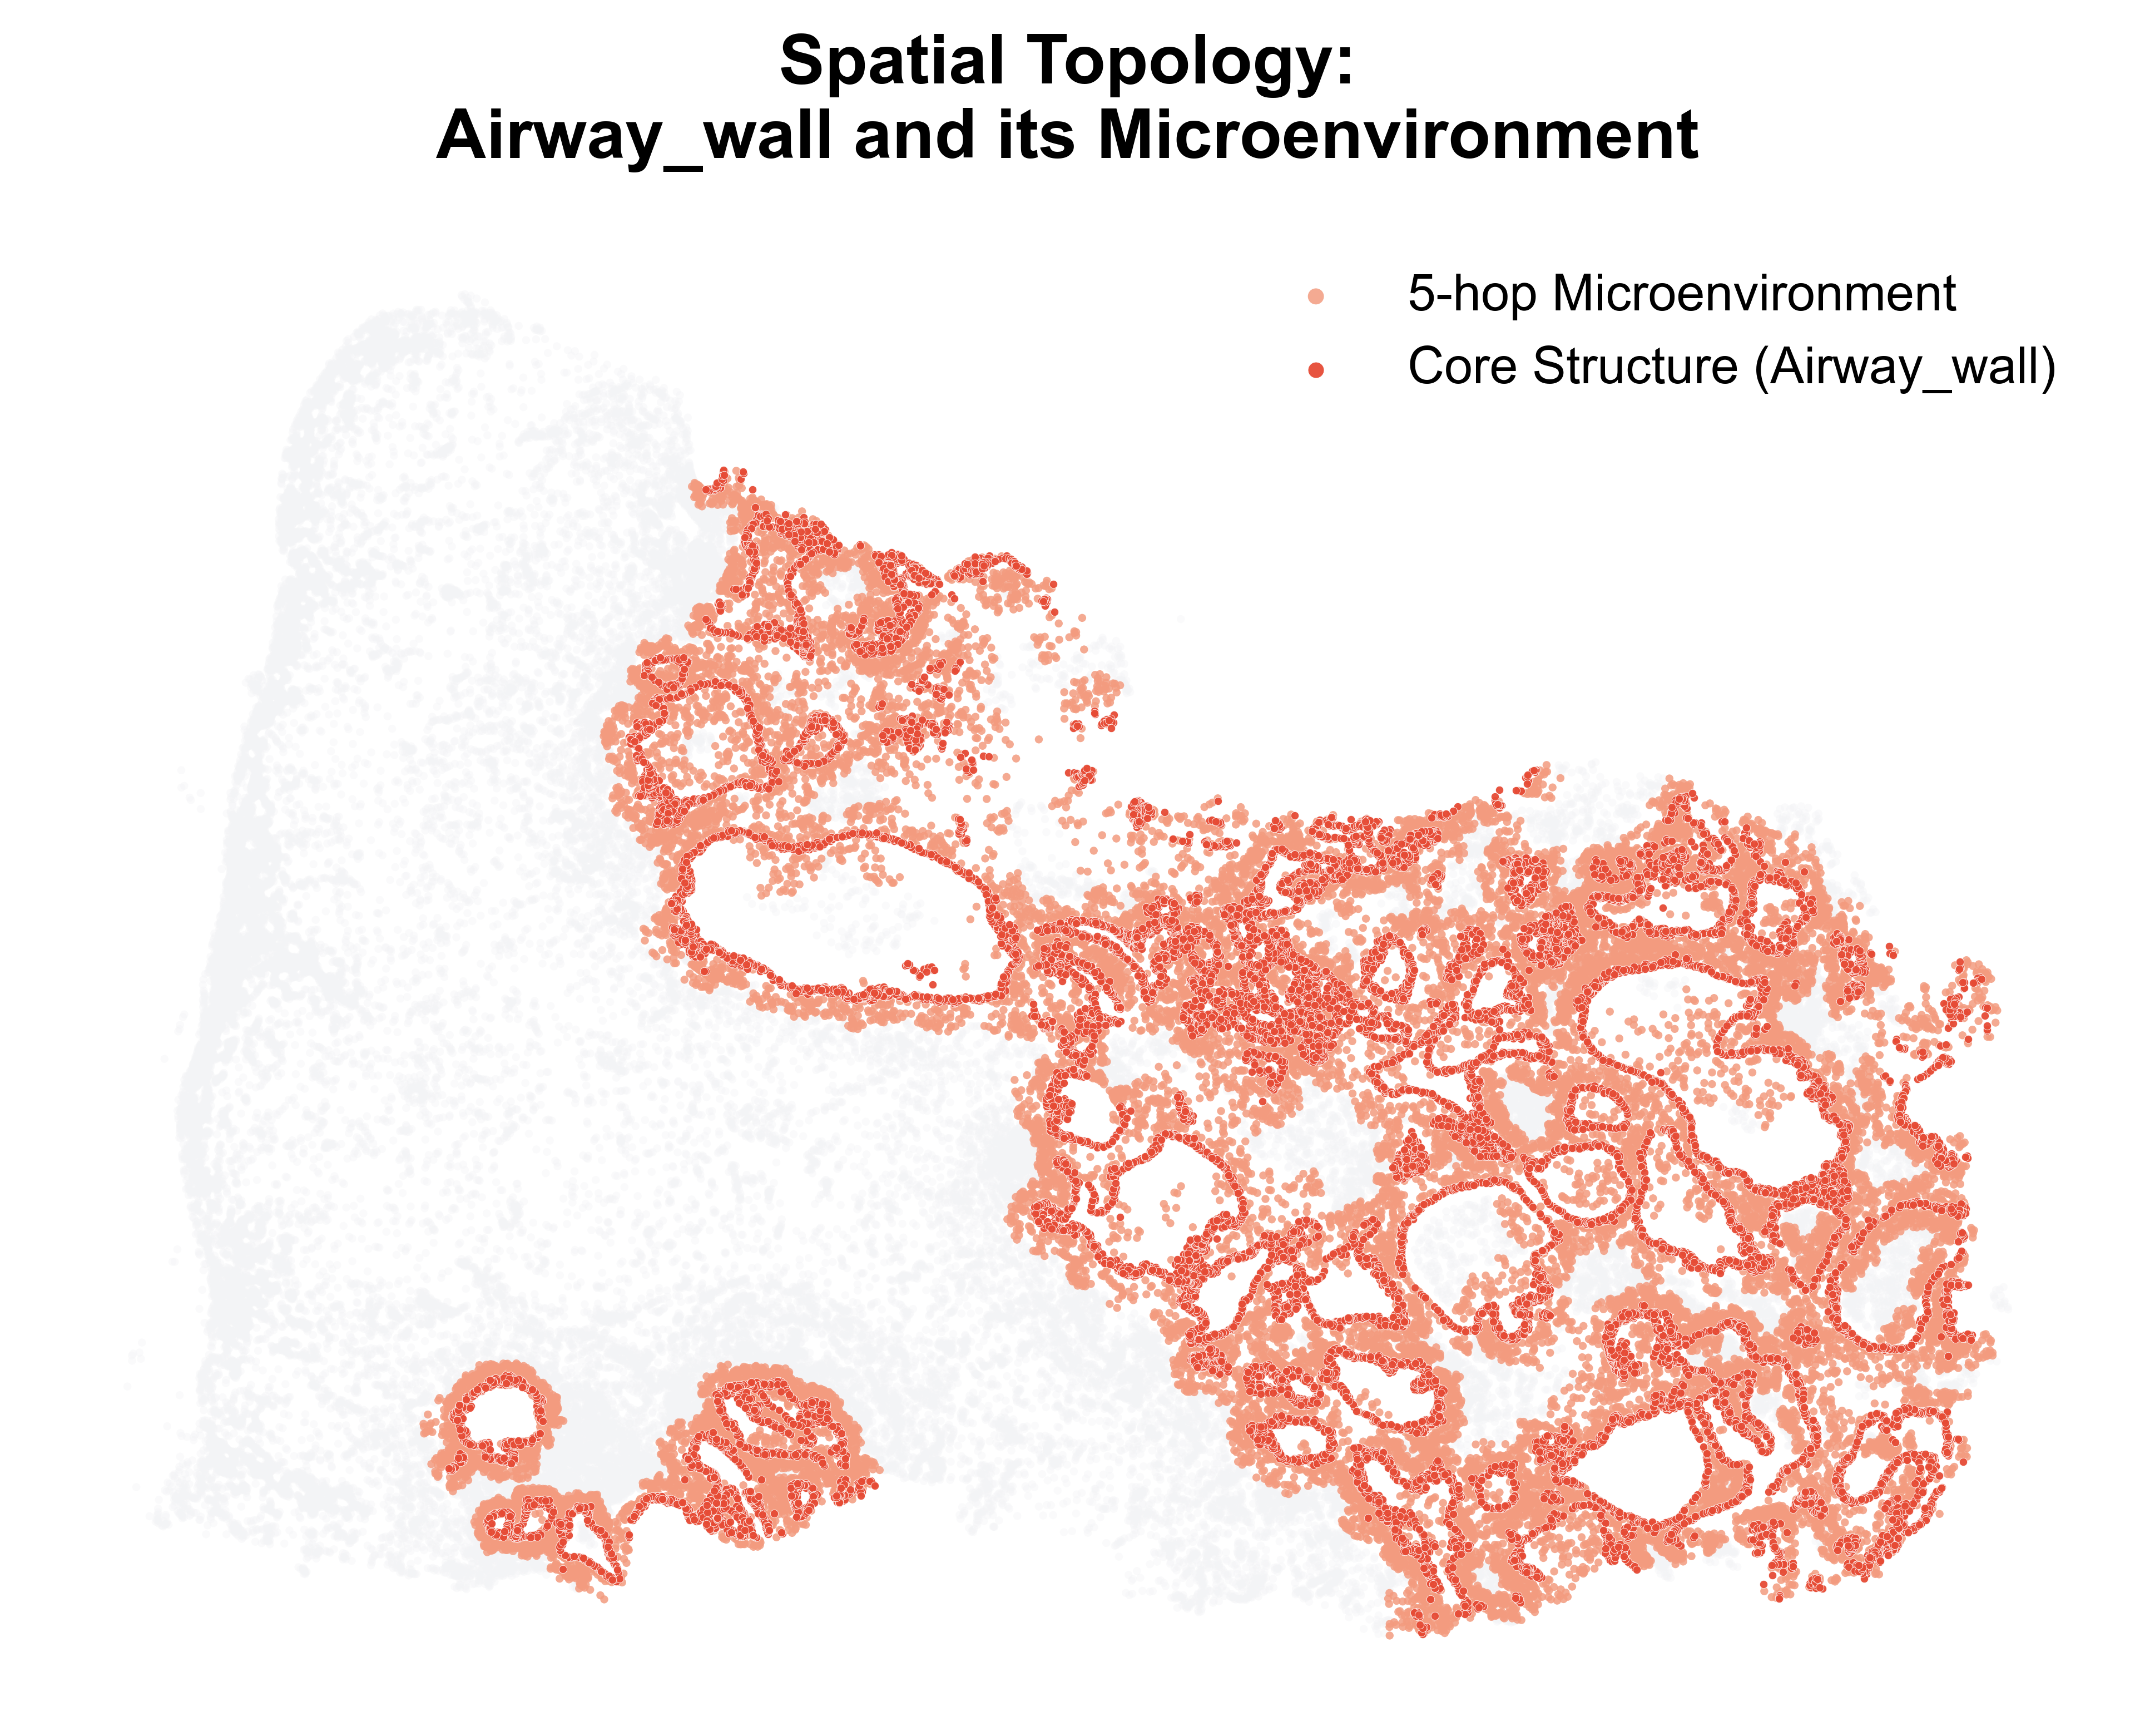

In [5]:
results = nh.run_cell_type_neighborhood_analysis(
    adata=adata,
    target_regions=TARGET_REGIONS,
    hops=HOPS,
    structure_col=STRUCTURE_COL,
    cell_type_col=CELL_TYPE_COL,
    output_dir=OUTPUT_DIR,
    selected_cell_types=TARGET_CELL_TYPES,
)


In [6]:
display(Markdown("### Generated outputs"))

for p in results["csv_paths"]:
    display(Markdown(f"- 📄 `{p}`"))

for p in results["figure_paths"]:
    display(Markdown(f"- 🖼️ `{p}`"))


### Generated outputs

- 📄 `outputs\neighborhood\All_CellType_Proportions_5hop.csv`

- 🖼️ `outputs\neighborhood\Barplot_All_Microenvironment_5hop.png`

- 🖼️ `outputs\neighborhood\Spatial_Topology_Airway_wall_Microenvironment_5hop.png`